In [ ]:
import dash
import plotly.graph_objects as go
import plotly.io as pio
from dash.dependencies import Input, Output
import pandas as pd
import numpy as np
from pymatgen.core import Element
import warnings

warnings.filterwarnings("ignore")

import pymatviz as pmz
import matplotlib.pyplot as plt
from matplotlib import colormaps

First we extract all stable combinations from the permuations. Here we use a different tau cutoff for the vacancy ordered HDPs based on experimental data available in M.G. Brik and I.V. Kity, J. of Physics and Chemistry of Solids (2011), DOI: 10.1016/j.jpcs.2011.07.016 

In [ ]:
AllCands = pd.read_csv("../HDP_PermuationMaker/All_HDP_Permutations.csv")
NoVacs = AllCands[AllCands["B2"] != "Vac"]
AllVacs = AllCands[AllCands["B2"] == "Vac"]

print(
    "All Combs:",
    AllCands.shape,
    "\nWithout Vacs:",
    NoVacs.shape,
    "\nVO-HDPS:",
    AllVacs.shape,
)
NoVacs.head()
StableNoVacs = NoVacs[NoVacs["tau"] <= 4.18]
vactau = 5.46  # Highest tau found for Cs2SeCl6
StableVacs = AllVacs[AllVacs["tau"] <= vactau]
# print(StableVacs[StableVacs['A'] == 'Cs'].tail(20))
StableHDPs = pd.concat([StableNoVacs, StableVacs], axis=0, join="inner")
# print(StableHDPs.tail(15))

print(
    "\nStable Comps All:",
    StableHDPs.shape,
    "\nWithout Vacs:",
    StableNoVacs.shape,
    "\nVO-HDPs:",
    StableVacs.shape,
)

StableCsHDPS = StableHDPs[StableHDPs["A"] == "Cs"]
##Filter out the elements without a PAW potential
ElNoPAWs = ["Bk", "Cf", "Es", "Fm", "Md", "No", "Lr"]
StableCsHDPS.loc[:, "NotSim"] = StableCsHDPS.apply(
    lambda row: row["B1"] in ElNoPAWs or row["B2"] in ElNoPAWs, axis=1
)

SimCsHDPs = StableCsHDPS[StableCsHDPS["NotSim"] == False]
SimCsHDPs["comp_name"] = SimCsHDPs.apply(
    lambda row: f"{row['A']}{row['B1']}{row['B2']}{row['X']}", axis=1
)
SimCsHDPs.set_index("comp_name").to_csv("ToSimulateComps.csv")
print(
    "\nStable Cs HDPs:", StableCsHDPS.shape, "\nCs HDPs to simulate:", SimCsHDPs.shape
)

All Combs: (47012, 15) 
Without Vacs: (42860, 15) 
VO-HDPS: (4152, 15)

Stable Comps All: (13277, 15) 
Without Vacs: (11275, 15) 
VO-HDPs: (2002, 15)

Stable Cs HDPs: (2953, 16) 
Cs HDPs to simulate: (2680, 17)


Now filter out unique elements for Asite and Bsite and construct data dictioniary for fitting

In [ ]:
Bsites = list(set(list(StableHDPs["B1"].unique()) + list(StableHDPs["B2"].unique())))
Bsites.remove("Vac")
Bsites.sort()
Asites = list(StableHDPs["A"].unique())
Asites.sort()
# print(Bsites,'\n', Asites)

eldata = {elem.symbol: np.zeros(2) for elem in Element}
for el in Asites:
    eldata[el][0] = 1

for el in Bsites:
    eldata[el][1] = 1

xsites = list(StableHDPs["X"].unique())

for el in xsites:
    # Halides we want separately colored
    eldata[el] = np.array([2.0, 2.0])

print(eldata)

{'H': array([0., 0.]), 'He': array([0., 0.]), 'Li': array([1., 1.]), 'Be': array([0., 1.]), 'B': array([0., 1.]), 'C': array([0., 0.]), 'N': array([0., 1.]), 'O': array([0., 0.]), 'F': array([2., 2.]), 'Ne': array([0., 0.]), 'Na': array([1., 1.]), 'Mg': array([1., 1.]), 'Al': array([0., 1.]), 'Si': array([0., 1.]), 'P': array([0., 1.]), 'S': array([0., 1.]), 'Cl': array([2., 2.]), 'Ar': array([0., 0.]), 'K': array([1., 1.]), 'Ca': array([1., 1.]), 'Sc': array([0., 1.]), 'Ti': array([1., 1.]), 'V': array([1., 1.]), 'Cr': array([1., 1.]), 'Mn': array([1., 1.]), 'Fe': array([1., 1.]), 'Co': array([1., 1.]), 'Ni': array([0., 1.]), 'Cu': array([1., 1.]), 'Zn': array([1., 1.]), 'Ga': array([0., 1.]), 'Ge': array([0., 1.]), 'As': array([0., 1.]), 'Se': array([0., 1.]), 'Br': array([2., 2.]), 'Kr': array([0., 0.]), 'Rb': array([1., 1.]), 'Sr': array([1., 1.]), 'Y': array([0., 1.]), 'Zr': array([0., 1.]), 'Nb': array([0., 1.]), 'Mo': array([0., 1.]), 'Tc': array([0., 1.]), 'Ru': array([0., 1.])

In [ ]:
blues = ["rgb(0, 51, 128)", "rgb(23, 162, 184)"]
sequential_colors = [
    [(0, "rgb(0, 144, 0)"), (1, "rgb(180,90,180)")],  # Red scale
    [(0, blues[0]), (1, "rgb(180,90,180)")],  # Blue scale
]

colorbars = [
    dict(title=f"Metric {idx + 1}", orientation="h", showscale=False)
    for idx in range(2)
]

fig = pmz.ptable_heatmap_splits_plotly(
    data=eldata,
    orientation="diagonal",
    colorscale=sequential_colors,
    colorbar=None,
    on_empty="show",
    split_value_fmt=None,
    symbol_kwargs=dict(font_size=18),
    # subplot_kwargs= dict(showscale=False)
)
fig.update_layout(font=dict(weight="bold"))
fig.show()
pmz.io.save_and_compress_svg(fig, filename="HDPptable.svg")

In [ ]:
colorbars = [
    dict(title=f"Metric {idx + 1}", orientation="h", showscale=False)
    for idx in range(2)
]

fig = pmz.ptable_heatmap_splits_plotly(
    data=eldata,
    orientation="diagonal",
    element_symbol_map=dict(Li="El", F="El"),
    colorscale=sequential_colors,
    colorbar=None,
    on_empty="show",
    split_value_fmt=None,
    symbol_kwargs=dict(font_size=18),
    # subplot_kwargs= dict(showscale=False)
)
fig.update_layout(font=dict(weight="bold"))
fig.show()
pmz.io.save_and_compress_svg(fig, filename="HDPptable_withEl.svg")

In [ ]:
StableCsHDPS["blockB1"] = StableCsHDPS.apply(
    lambda row: Element(row["B1"]).block, axis=1
)
StableCsHDPS["blockB2"] = StableCsHDPS.apply(
    lambda row: Element(row["B2"]).block if row["B2"] != "Vac" else "Vac", axis=1
)
StableCsHDPS["Bpairing"] = StableCsHDPS.apply(
    lambda row: (
        "-".join([row["blockB1"], row["blockB2"]])
        if row["blockB1"] < row["blockB2"]
        else "-".join([row["blockB2"], row["blockB1"]])
    ),
    axis=1,
)
StableCsHDPS.head()
SimCsHDPs["blockB1"] = SimCsHDPs.apply(lambda row: Element(row["B1"]).block, axis=1)
SimCsHDPs["blockB2"] = SimCsHDPs.apply(
    lambda row: Element(row["B2"]).block if row["B2"] != "Vac" else "Vac", axis=1
)
SimCsHDPs["Bpairing"] = SimCsHDPs.apply(
    lambda row: (
        "-".join([row["blockB1"], row["blockB2"]])
        if row["blockB1"] < row["blockB2"]
        else "-".join([row["blockB2"], row["blockB1"]])
    ),
    axis=1,
)
print(SimCsHDPs["Bpairing"].unique())

['p-s' 'd-s' 'f-s' 's-s' 'd-p' 'p-p' 'd-d' 'd-f' 'f-p' 'f-f' 'Vac-p'
 'Vac-d' 'Vac-f']


In [ ]:
def bpairing_barplot(
    stable_bar_df, sim_bar_df, *, title="Counts of different B-B' block pairings", fn=""
):
    allpairings = [
        "Vac-d",
        "Vac-f",
        "Vac-p",
        "Vac-s",
        "d-d",
        "d-f",
        "d-p",
        "d-s",
        "f-f",
        "f-p",
        "f-s",
        "f-dummy",
        "p-p",
        "p-s",
        "p-dumm1y",
        "p-dummy2",
        "s-s",
    ]
    colors = {
        label: color for label, color in zip(allpairings, colormaps["tab20c"].colors)
    }

    species = list(sim_bar_df.keys())
    # paircounts = bar_dict.values()

    def return_paircounts(bar_df, pair):
        list_of_counts = []
        for key in bar_df.keys():
            list_of_counts.append(bar_df[key][pair])
        return list_of_counts

    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    width = 0.2
    offset = 0

    maxpairs = sim_bar_df[species[0]].keys()
    x = 3 * np.arange(len(species))
    multiplier = 0

    for pair in maxpairs:
        offset = width * multiplier
        p = ax.bar(
            x + offset,
            return_paircounts(stable_bar_df, pair),
            width=width,
            color=colors[pair],
            alpha=0.2,
        )
        ax.bar_label(p, fontsize=12, rotation=0)
        ax.bar(
            x + offset,
            return_paircounts(sim_bar_df, pair),
            width=width,
            label=pair,
            color=colors[pair],
            alpha=1,
        )
        multiplier += 1

    ax.set_xticks(x + len(maxpairs) / 2 * width, species, fontsize=14)
    ax.legend(
        ncols=2,
        title="B-site pairing:",
        fontsize=13,
        title_fontsize=14,
        loc="upper right",
    )
    ax.yaxis.grid()

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Compound group", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    # fig.tight_layout()
    # plt.show()

    if fn != "":
        plt.savefig(fn, dpi=200)
        plt.show()
    else:
        plt.show()

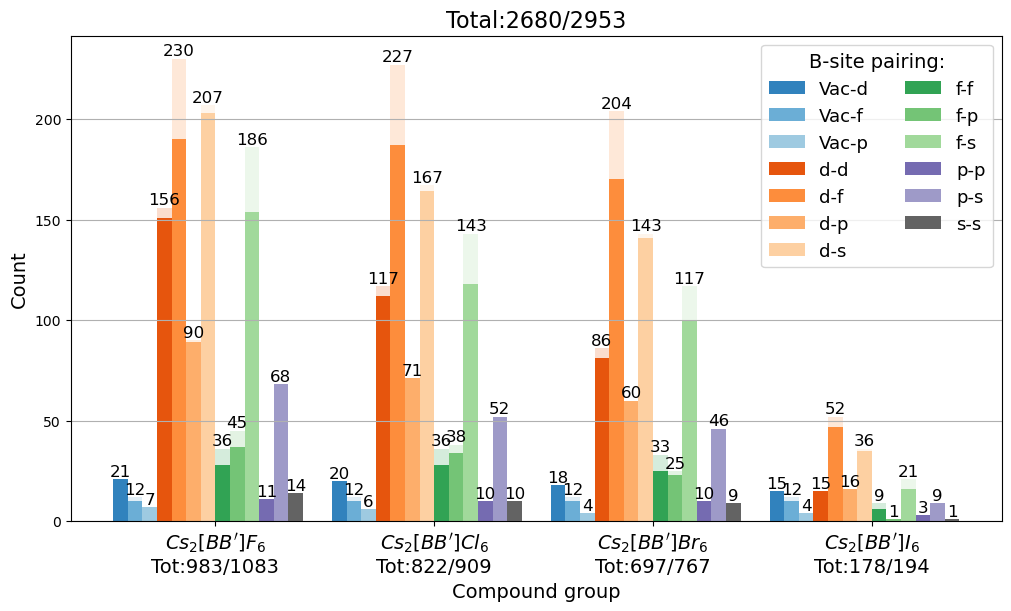

In [ ]:
###select data to plot
StableCsF = (
    StableCsHDPS.query('A=="Cs" & X == "F"')["Bpairing"]
    .value_counts()
    .sort_index(axis=0)
)
StableCsCl = (
    StableCsHDPS.query('A=="Cs" & X == "Cl"')["Bpairing"]
    .value_counts()
    .sort_index(axis=0)
)
StableCsBr = (
    StableCsHDPS.query('A=="Cs" & X == "Br"')["Bpairing"]
    .value_counts()
    .sort_index(axis=0)
)
StableCsI = (
    StableCsHDPS.query('A=="Cs" & X == "I"')["Bpairing"]
    .value_counts()
    .sort_index(axis=0)
)

Stablebar_df = pd.DataFrame(
    {
        f"$Cs_2[BB']F_6$\ntot:{StableCsF.sum()}": StableCsF,
        f"$Cs_2[BB']Cl_6$\ntot:{StableCsCl.sum()}": StableCsCl,
        f"$Cs_2[BB']Br_6$\ntot:{StableCsBr.sum()}": StableCsBr,
        f"$Cs_2[BB']I_6$\ntot:{StableCsI.sum()}": StableCsI,
    },
    index=StableCsF.keys(),
).fillna(0)

###select data to plot
SimCsF = (
    SimCsHDPs.query('A=="Cs" & X == "F"')["Bpairing"].value_counts().sort_index(axis=0)
)
SimCsCl = (
    SimCsHDPs.query('A=="Cs" & X == "Cl"')["Bpairing"].value_counts().sort_index(axis=0)
)
SimCsBr = (
    SimCsHDPs.query('A=="Cs" & X == "Br"')["Bpairing"].value_counts().sort_index(axis=0)
)
SimCsI = (
    SimCsHDPs.query('A=="Cs" & X == "I"')["Bpairing"].value_counts().sort_index(axis=0)
)

Simbar_df = pd.DataFrame(
    {
        f"$Cs_2[BB']F_6$\nTot:{SimCsF.sum()}/{StableCsF.sum()}": SimCsF,
        f"$Cs_2[BB']Cl_6$\nTot:{SimCsCl.sum()}/{StableCsCl.sum()}": SimCsCl,
        f"$Cs_2[BB']Br_6$\nTot:{SimCsBr.sum()}/{StableCsBr.sum()}": SimCsBr,
        f"$Cs_2[BB']I_6$\nTot:{SimCsI.sum()}/{StableCsI.sum()}": SimCsI,
    },
    index=SimCsF.keys(),
).fillna(0)

bpairing_barplot(
    Stablebar_df,
    Simbar_df,
    title=f"Total:{SimCsF.sum() + SimCsCl.sum() + SimCsBr.sum() + SimCsI.sum()}/{StableCsF.sum() + StableCsCl.sum() + StableCsBr.sum() + StableCsI.sum()}",
    fn="CsHDPs_Bpairings.png",
)